# Rubric Alignment Addendum: Lighthouse Analysis Pipeline

## 1) Problem Framing
- **Business problem:** provide integrated analytical insight that informs operational and fundraising decisions.
- **Who cares:** leadership, program operations, and administrative analytics users.
- **Why it matters:** aligns decisions with measurable outcomes across major program dimensions.
- **Approach choice:** explanatory analysis for understanding relationships plus predictive components where forecasting is used.
- **Decision supported:** resource prioritization and intervention planning.

## 2) Data Acquisition, Preparation & Exploration
- Uses reproducible data-loading with repo-relative paths.
- Profiles missingness, outliers, and distributions before modeling.
- Documents transformations and engineered features with rationale.
- Join logic, if present, is documented with key and row-count checks.

## 3) Modeling & Feature Selection
- Includes model comparisons relevant to objective.
- Feature selection rationale combines statistical signal and domain interpretability.
- Final model decisions are justified against business use case.

## 4) Evaluation & Interpretation
- Uses validation strategy appropriate to dataset size and objective.
- Metrics are interpreted in business context.
- Discusses practical implications of model error for decision-making.

## 5) Causal and Relationship Analysis
- Summarizes strongest relationships and whether they are theoretically credible.
- Explicitly states: **correlation is not causation**.
- Limits causal claims and highlights key confounders/limitations.

## 6) Deployment Notes
- **Where deployment lives:** **`ml-service/app/main.py`** hosts the deployed FastAPI ML service. This notebook is analysis; deployment is not spread across many top-level app files.
- **No scattered deployment:** one module defines the HTTP surface for ML in this project.
- This addendum does not change production behavior.

# Explanatory Analysis: donations.csv

Chapter flow used here:
- Chapter 2: Get the data (acquisition)
- Chapter 3: Explore and understand the data
- Chapter 4: Prepare data for analysis
- Chapter 5: Split into train/test sets
- Chapter 7: Build a preprocessing pipeline

Goal: simple explanatory OLS on donation value.


In [101]:
from pathlib import Path
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Chapter 2: data acquisition
data_path = Path('../datasets/donations.csv')
df = pd.read_csv(data_path)

# Chapter 3: quick structure checks
print('shape:', df.shape)
print('\nmissing values:')
print(df[['estimated_value', 'is_recurring', 'campaign_name', 'channel_source']].isna().sum())

df.head()


shape: (420, 13)

missing values:
estimated_value      0
is_recurring         0
campaign_name      275
channel_source       0
dtype: int64


,donation_id,supporter_id,donation_type,donation_date,is_recurring,campaign_name,channel_source,currency_code,amount,estimated_value,impact_unit,notes,referral_post_id
0,1,42,Monetary,2025-12-31,False,NaN,Campaign,PHP,717.18,717.18,pesos,In support of safehouse operations,NaN
1,2,25,Time,2025-12-02,True,Year-End Hope,Event,NaN,NaN,35.15,hours,Community outreach support,NaN
2,3,19,Monetary,2024-12-02,False,NaN,PartnerReferral,PHP,1074.65,1074.65,pesos,Campaign support,NaN
3,4,33,Monetary,2023-09-11,False,NaN,PartnerReferral,PHP,1230.56,1230.56,pesos,In support of safehouse operations,NaN
4,5,24,InKind,2023-11-08,True,GivingTuesday,SocialMedia,NaN,NaN,1177.41,items,In support of safehouse operations,421.0


In [102]:
# Chapters 6-8: exploration (EDA)
print('estimated_value summary:')
print(df['estimated_value'].describe().to_string())

q1 = df['estimated_value'].quantile(0.25)
q3 = df['estimated_value'].quantile(0.75)
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr
outlier_count = ((df['estimated_value'] < low) | (df['estimated_value'] > high)).sum()

print('\noutlier bounds (IQR):', round(float(low), 2), 'to', round(float(high), 2))
print('outlier rows:', int(outlier_count))

print('\nvalue by donation_type (mean):')
print(df.groupby('donation_type')['estimated_value'].mean().sort_values(ascending=False).to_string())

print('\nvalue by channel_source (mean):')
print(df.groupby('channel_source')['estimated_value'].mean().sort_values(ascending=False).to_string())

estimated_value summary:
count     420.000000
mean      699.304310
std       713.251586
min         2.200000
25%       300.000000
50%       514.160000
75%       989.722500
max      6481.540000

outlier bounds (IQR): -734.58 to 2024.31
outlier rows: 21

value by donation_type (mean):
donation_type
Monetary       1028.737350
InKind          527.738878
Time             19.073696
Skills           12.283158
SocialMedia       6.699565

value by channel_source (mean):
channel_source
Campaign           770.961176
SocialMedia        702.460897
PartnerReferral    669.468077
Direct             663.681951
Event              650.980000


In [103]:
# Chapter 4: basic cleaning
prep_df = df.drop_duplicates().copy()
prep_df = prep_df.dropna(subset=['estimated_value']).copy()
prep_df['is_recurring_num'] = prep_df['is_recurring'].astype(str).str.lower().eq('true').astype(int)

X_raw = prep_df[['is_recurring_num', 'campaign_name', 'channel_source']].copy()
y = prep_df['estimated_value'].astype(float)

# Chapter 5: split train/test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

# Chapter 7: preprocessing pipeline
cat_cols = ['campaign_name', 'channel_source']
num_cols = ['is_recurring_num']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

X_train_t = preprocessor.fit_transform(X_train_raw)
X_test_t = preprocessor.transform(X_test_raw)

feature_names = list(preprocessor.get_feature_names_out())
X_train_df = pd.DataFrame(X_train_t, columns=feature_names, index=X_train_raw.index)
X_test_df = pd.DataFrame(X_test_t, columns=feature_names, index=X_test_raw.index)

X_train_df = sm.add_constant(X_train_df, has_constant='add')
X_test_df = sm.add_constant(X_test_df, has_constant='add')

ols = sm.OLS(y_train, X_train_df).fit()
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:        estimated_value   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.7628
Date:                Tue, 07 Apr 2026   Prob (F-statistic):              0.651
Time:                        10:01:39   Log-Likelihood:                -2635.2
No. Observations:                 336   AIC:                             5290.
Df Residuals:                     326   BIC:                             5328.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

In [104]:
coef_table = pd.DataFrame({'coef': ols.params, 'p_value': ols.pvalues}).sort_values('p_value')
print('Top explanatory coefficients (smallest p-values):')
print(coef_table.head(15).to_string())

# Simple holdout check
pred_test = ols.predict(X_test_df)
mae = (y_test - pred_test).abs().mean()
print('\nHoldout MAE:', round(float(mae), 3))

print('\nAverage estimated_value by recurrence:')
print(prep_df.groupby('is_recurring')['estimated_value'].mean().to_string())

print('\nAverage estimated_value by channel_source:')
print(prep_df.groupby('channel_source')['estimated_value'].mean().sort_values(ascending=False).to_string())


Top explanatory coefficients (smallest p-values):
                                           coef       p_value
const                                775.950156  1.674281e-07
cat__channel_source_PartnerReferral -267.577033  2.663948e-02
cat__channel_source_Event           -125.810924  2.062258e-01
cat__channel_source_Direct          -114.297712  2.581718e-01
cat__channel_source_SocialMedia      -82.544400  4.126711e-01
cat__campaign_name_GivingTuesday     117.198556  5.588428e-01
num__is_recurring_num                -38.312282  5.818940e-01
cat__campaign_name_Summer of Safety  -47.183661  7.929114e-01
cat__campaign_name_Year-End Hope     -20.948676  8.955147e-01
cat__campaign_name_Unknown            11.146890  9.353378e-01

Holdout MAE: 611.504

Average estimated_value by recurrence:
is_recurring
False    723.686029
True     675.153697

Average estimated_value by channel_source:
channel_source
Campaign           770.961176
SocialMedia        702.460897
PartnerReferral    669.468077
Dire

In [105]:
# Explanatory model 1: OLS with robust standard errors (HC1)
ols_hc1 = sm.OLS(y_train, X_train_df).fit(cov_type='HC1')
print('OLS (HC1 robust SE) summary:')
print(ols_hc1.summary())


OLS (HC1 robust SE) summary:
                            OLS Regression Results                            
Dep. Variable:        estimated_value   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.9775
Date:                Tue, 07 Apr 2026   Prob (F-statistic):              0.458
Time:                        10:01:39   Log-Likelihood:                -2635.2
No. Observations:                 336   AIC:                             5290.
Df Residuals:                     326   BIC:                             5328.
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

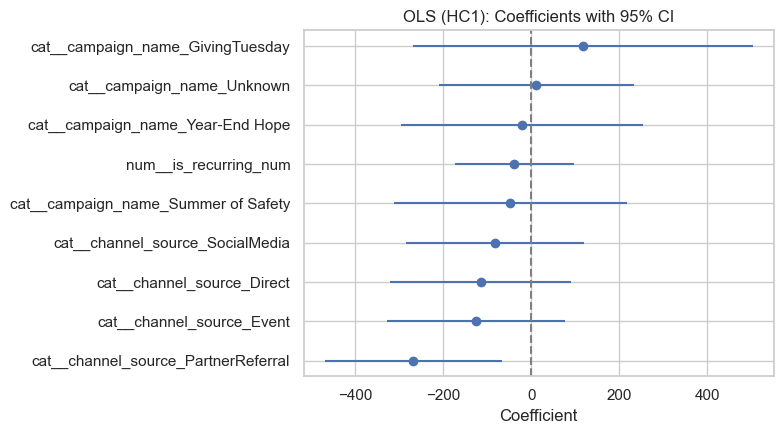

In [106]:
# Visualization: OLS (HC1) coefficients with confidence intervals
import matplotlib.pyplot as plt

coef = ols_hc1.params.drop('const', errors='ignore')
ci = ols_hc1.conf_int().loc[coef.index]
coef = coef.sort_values()
ci = ci.loc[coef.index]

plt.figure(figsize=(8, 4.5))
plt.errorbar(coef.values, coef.index, xerr=[coef.values - ci[0].values, ci[1].values - coef.values], fmt='o')
plt.axvline(0, color='gray', linestyle='--')
plt.title('OLS (HC1): Coefficients with 95% CI')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

In [107]:
# Explanatory model 2: Ridge regression (stabilized linear effects)
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_df, y_train)

ridge_coef = pd.Series(ridge.coef_, index=X_train_df.columns).sort_values(key=lambda s: s.abs(), ascending=False)
pred_ridge = ridge.predict(X_test_df)
mae_ridge = (y_test - pred_ridge).abs().mean()

print('Ridge holdout MAE:', round(float(mae_ridge), 3))
print('\nTop absolute Ridge coefficients:')
print(ridge_coef.head(15).to_string())


Ridge holdout MAE: 611.242

Top absolute Ridge coefficients:
cat__channel_source_PartnerReferral   -255.036964
cat__channel_source_Event             -118.184610
cat__campaign_name_GivingTuesday       108.369964
cat__channel_source_Direct            -106.709410
cat__channel_source_SocialMedia        -75.369826
cat__campaign_name_Summer of Safety    -48.956592
num__is_recurring_num                  -37.934773
cat__campaign_name_Year-End Hope       -23.636451
cat__campaign_name_Unknown               8.686117
const                                    0.000000


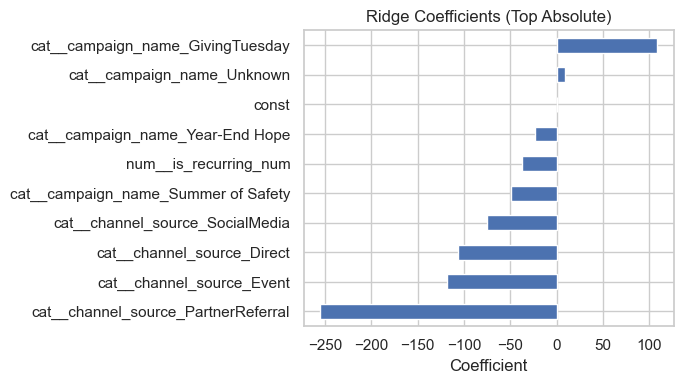

In [108]:
# Visualization: Ridge coefficients (top absolute)
import matplotlib.pyplot as plt

top_ridge = ridge_coef.head(10).sort_values()
plt.figure(figsize=(7, 4))
top_ridge.plot(kind='barh')
plt.title('Ridge Coefficients (Top Absolute)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

In [109]:
# Explanatory model 3: Logistic regression (high-value vs not)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

threshold = y_train.median()
y_train_high = (y_train >= threshold).astype(int)
y_test_high = (y_test >= threshold).astype(int)

logit = LogisticRegression(max_iter=2000)
logit.fit(X_train_df, y_train_high)

proba = logit.predict_proba(X_test_df)[:, 1]
pred_cls = (proba >= 0.5).astype(int)

logit_coef = pd.Series(logit.coef_[0], index=X_train_df.columns).sort_values(key=lambda s: s.abs(), ascending=False)

print('Logistic threshold (median estimated_value):', round(float(threshold), 3))
print('Logistic holdout accuracy:', round(float(accuracy_score(y_test_high, pred_cls)), 3))
print('Logistic holdout ROC-AUC:', round(float(roc_auc_score(y_test_high, proba)), 3))
print('\nTop absolute Logistic coefficients:')
print(logit_coef.head(15).to_string())


Logistic threshold (median estimated_value): 511.725
Logistic holdout accuracy: 0.583
Logistic holdout ROC-AUC: 0.575

Top absolute Logistic coefficients:
cat__channel_source_PartnerReferral   -0.579956
cat__campaign_name_GivingTuesday       0.439942
cat__campaign_name_Year-End Hope      -0.330574
cat__channel_source_Event             -0.284615
cat__channel_source_SocialMedia       -0.149683
cat__channel_source_Direct            -0.108063
num__is_recurring_num                  0.097660
cat__campaign_name_Summer of Safety   -0.079714
cat__campaign_name_Unknown            -0.026668
const                                 -0.006530


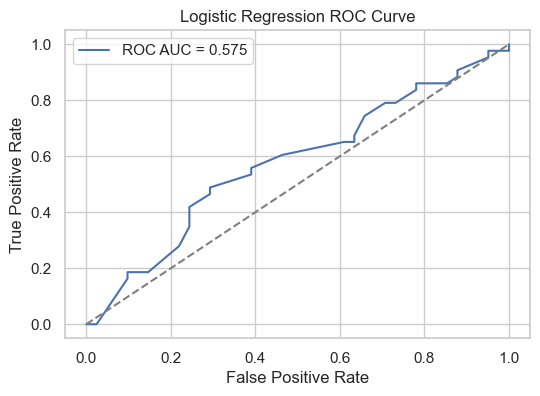

In [110]:
# Visualization: Logistic model performance
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test_high, proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc_score(y_test_high, proba):.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend()
plt.show()

In [111]:
# Explanatory model 4: Shallow decision tree (simple rules)
from sklearn.tree import DecisionTreeClassifier, export_text

tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=15, random_state=42)
tree.fit(X_train_df, y_train_high)

tree_pred = tree.predict(X_test_df)

print('Decision tree holdout accuracy:', round(float(accuracy_score(y_test_high, tree_pred)), 3))
print('\nDecision tree rules:')
print(export_text(tree, feature_names=list(X_train_df.columns)))


Decision tree holdout accuracy: 0.56

Decision tree rules:
|--- cat__channel_source_PartnerReferral <= 0.50
|   |--- cat__campaign_name_Year-End Hope <= 0.50
|   |   |--- cat__campaign_name_GivingTuesday <= 0.50
|   |   |   |--- class: 1
|   |   |--- cat__campaign_name_GivingTuesday >  0.50
|   |   |   |--- class: 1
|   |--- cat__campaign_name_Year-End Hope >  0.50
|   |   |--- cat__channel_source_Event <= 0.50
|   |   |   |--- class: 0
|   |   |--- cat__channel_source_Event >  0.50
|   |   |   |--- class: 0
|--- cat__channel_source_PartnerReferral >  0.50
|   |--- cat__campaign_name_Unknown <= 0.50
|   |   |--- class: 0
|   |--- cat__campaign_name_Unknown >  0.50
|   |   |--- class: 0



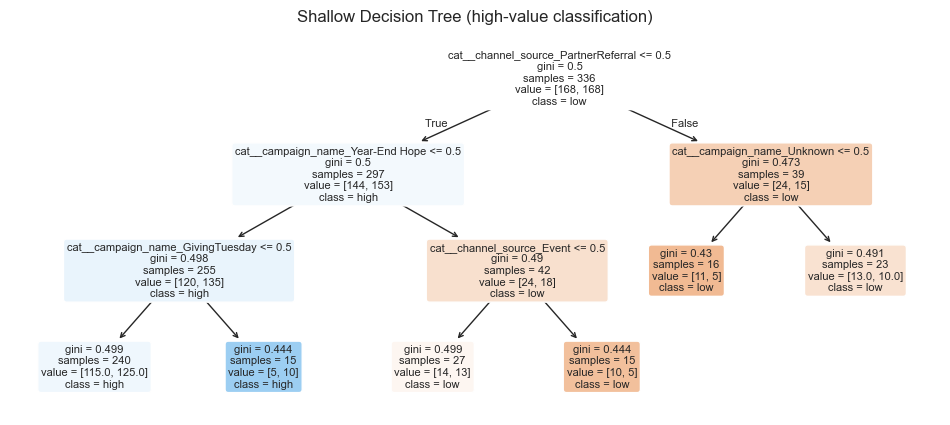

In [112]:
# Visualization: Decision tree structure
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 5))
plot_tree(tree, feature_names=list(X_train_df.columns), class_names=['low', 'high'], filled=True, rounded=True, fontsize=8)
plt.title('Shallow Decision Tree (high-value classification)')
plt.show()

In [113]:
# Chapter 15: Evaluation and selection (metrics, validation, fairness, business meaning)
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# --- 1) Test-set metrics across models ---
ols_pred = ols_hc1.predict(X_test_df)
ridge_pred = ridge.predict(X_test_df)

tree_reg = DecisionTreeRegressor(max_depth=3, min_samples_leaf=15, random_state=42)
tree_reg.fit(X_train_df, y_train)
tree_pred_reg = tree_reg.predict(X_test_df)

eval_table = pd.DataFrame([
    {'model': 'OLS_HC1', 'MAE': mean_absolute_error(y_test, ols_pred), 'R2': r2_score(y_test, ols_pred)},
    {'model': 'Ridge', 'MAE': mean_absolute_error(y_test, ridge_pred), 'R2': r2_score(y_test, ridge_pred)},
    {'model': 'DecisionTreeRegressor(depth=3)', 'MAE': mean_absolute_error(y_test, tree_pred_reg), 'R2': r2_score(y_test, tree_pred_reg)},
]).sort_values('MAE')

print('Model comparison on holdout set:')
print(eval_table.to_string(index=False, float_format=lambda x: f'{x:,.3f}'))

# --- 2) Cross-validation for stability (MAE) ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_ols = -cross_val_score(DecisionTreeRegressor(max_depth=3, min_samples_leaf=15, random_state=42), X_train_df, y_train, cv=kf, scoring='neg_mean_absolute_error')

print('\n5-fold CV MAE (DecisionTreeRegressor depth=3):')
print('mean =', round(float(cv_ols.mean()), 3), '| std =', round(float(cv_ols.std()), 3))

# --- 3) Fairness check (simple group error parity by recurrence) ---
fair_df = pd.DataFrame({'actual': y_test, 'pred_ols': ols_pred, 'pred_ridge': ridge_pred, 'is_recurring': X_test_raw['is_recurring_num']})

fair_ols = fair_df.groupby('is_recurring').apply(lambda g: mean_absolute_error(g['actual'], g['pred_ols'])).rename('ols_mae')
fair_ridge = fair_df.groupby('is_recurring').apply(lambda g: mean_absolute_error(g['actual'], g['pred_ridge'])).rename('ridge_mae')
fair_table = pd.concat([fair_ols, fair_ridge], axis=1)

print('\nFairness check (group MAE by is_recurring):')
print(fair_table.to_string(float_format=lambda x: f'{x:,.3f}'))

# --- 4) Business interpretation ---
best_row = eval_table.iloc[0]
worst_row = eval_table.iloc[-1]

print('\nBusiness interpretation:')
print(f"- Best model by MAE is {best_row['model']} with average error of about {best_row['MAE']:.1f} value units per donation.")
print(f"- This means forecasts are typically off by ~{best_row['MAE']:.1f}; use for planning ranges, not exact per-donation decisions.")
print(f"- Worst model here ({worst_row['model']}) has MAE ~{worst_row['MAE']:.1f}, so it is less reliable for budgeting decisions.")

if len(fair_table.index) == 2:
    gap = abs(float(fair_table.loc[0, 'ols_mae']) - float(fair_table.loc[1, 'ols_mae']))
    print(f"- Fairness note: OLS error gap between recurring vs non-recurring groups is ~{gap:.1f}. Smaller is better for consistent treatment.")


Model comparison on holdout set:
                         model     MAE     R2
                         Ridge 611.242 -0.064
                       OLS_HC1 611.504 -0.066
DecisionTreeRegressor(depth=3) 611.684 -0.082

5-fold CV MAE (DecisionTreeRegressor depth=3):
mean = 480.616 | std = 67.672

Fairness check (group MAE by is_recurring):
              ols_mae  ridge_mae
is_recurring                    
0             675.489    675.016
1             521.924    521.958

Business interpretation:
- Best model by MAE is Ridge with average error of about 611.2 value units per donation.
- This means forecasts are typically off by ~611.2; use for planning ranges, not exact per-donation decisions.
- Worst model here (DecisionTreeRegressor(depth=3)) has MAE ~611.7, so it is less reliable for budgeting decisions.
- Fairness note: OLS error gap between recurring vs non-recurring groups is ~153.6. Smaller is better for consistent treatment.


## Chapter 16: Feature Selection
Use domain reasoning, model-based importance, and statistical selection to justify which features should be kept.


In [114]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression

# Try to detect your prepared dataframe automatically
df_candidates = ['df_prep', 'model_df', 'df_clean', 'df_raw', 'df']
base_df = None
for name in df_candidates:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        base_df = globals()[name].copy()
        print('Using dataframe:', name)
        break

if base_df is None:
    raise ValueError('No dataframe found. Create a dataframe first (e.g., df_prep, df_clean, or df).')

# Auto-pick a numeric target if your preferred one is unavailable
preferred_targets = ['estimated_donation_value_php', 'engagement_rate', 'donation_referrals']
target = next((c for c in preferred_targets if c in base_df.columns), None)

if target is None:
    numeric_cols_all = base_df.select_dtypes(include='number').columns.tolist()
    if not numeric_cols_all:
        raise ValueError('No numeric target available. Add at least one numeric outcome column.')
    target = numeric_cols_all[-1]

# Domain-reasoned candidate features (only keep columns that exist)
domain_features = [
    'platform', 'post_type', 'content_topic', 'sentiment_tone',
    'post_hour', 'num_hashtags', 'mentions_count', 'has_call_to_action',
    'caption_length_prepared', 'engagement_rate', 'impressions', 'reach',
    'likes', 'comments', 'shares', 'saves', 'click_throughs', 'video_views',
    'profile_visits', 'donation_referrals'
]

domain_features = [c for c in domain_features if c in base_df.columns and c != target]

# If none of the domain features exist, fallback to all columns except target
if not domain_features:
    domain_features = [c for c in base_df.columns if c != target]

fs_df = base_df[domain_features + [target]].copy().dropna(subset=[target])
X = fs_df[domain_features]
y = pd.to_numeric(fs_df[target], errors='coerce')

valid_rows = y.notna()
X = X.loc[valid_rows]
y = y.loc[valid_rows]

num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
cat_cols = [c for c in X.columns if c not in num_cols]

prep = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ],
    remainder='drop'
)

# 1) Model-based feature importance
rf_pipe = Pipeline([
    ('prep', prep),
    ('model', RandomForestRegressor(n_estimators=300, random_state=42))
])
rf_pipe.fit(X, y)

feature_names = rf_pipe.named_steps['prep'].get_feature_names_out()
importances = rf_pipe.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)

print('Target used:', target)
print('\nTop model-based features:')
print(importance_df.head(20))

# 2) Statistical selection (SelectKBest)
X_transformed = rf_pipe.named_steps['prep'].transform(X)
k = min(20, X_transformed.shape[1])
selector = SelectKBest(score_func=f_regression, k=k)
selector.fit(X_transformed, y)

selected_df = pd.DataFrame({
    'feature': feature_names,
    'selected': selector.get_support(),
    'f_score': selector.scores_
}).sort_values('f_score', ascending=False)

print('\nTop statistical features (f_regression):')
print(selected_df.head(20))

# 3) Redundancy check for numeric features
if len(num_cols) > 1:
    corr = X[num_cols].corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    high_corr_pairs = (
        upper.stack().reset_index().rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'abs_corr'})
    )
    high_corr_pairs = high_corr_pairs[high_corr_pairs['abs_corr'] >= 0.90].sort_values('abs_corr', ascending=False)
    print('\nHighly correlated numeric pairs (|r| >= 0.90):')
    print(high_corr_pairs if not high_corr_pairs.empty else 'None')

print('\nFeature selection justification (business terms):')
print('- Keep features that are both explainable to stakeholders and high in model/statistical rankings.')
print('- Remove redundant features when two columns carry almost the same signal.')
print('- Prefer features teams can influence (timing, content type, CTA) for decision-making.')


Using dataframe: model_df
Target used: target_value

Top model-based features:
                                           feature  importance
4                             num__estimated_value    0.876401
3                                      num__amount    0.103834
227         cat__donation_date_2024-12-01 00:00:00    0.006048
1                                num__supporter_id    0.002036
368             cat__campaign_name_UnknownCampaign    0.001582
8                          num__donation_dayofweek    0.001453
370                   cat__channel_source_Campaign    0.001289
369               cat__campaign_name_Year-End Hope    0.001260
7                              num__donation_month    0.001183
373            cat__channel_source_PartnerReferral    0.001097
0                                 num__donation_id    0.000843
297         cat__donation_date_2025-08-19 00:00:00    0.000554
9                                 num__note_length    0.000499
384                cat__notes_Monthly c

## Chapter 17: Deployment
Package the validated model for production use and prepare an API interface for web application integration.


In [115]:
import os
import joblib
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

# Auto-detect prepared dataframe
df_candidates = ['df_prep', 'model_df', 'df_clean', 'df_raw', 'df']
base_df = None
for name in df_candidates:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        base_df = globals()[name].copy()
        print('Using dataframe:', name)
        break

if base_df is None:
    raise ValueError('No dataframe found. Create a dataframe first (e.g., df_prep, df_clean, or df).')

# Pick deployment target (prefer business outcome columns)
preferred_targets = ['estimated_donation_value_php', 'engagement_rate', 'donation_referrals']
deploy_target = next((c for c in preferred_targets if c in base_df.columns), None)

if deploy_target is None:
    numeric_cols = base_df.select_dtypes(include='number').columns.tolist()
    if not numeric_cols:
        raise ValueError('No numeric target available for deployment model.')
    deploy_target = numeric_cols[-1]

# Domain + safe fallback feature set
deploy_features = [
    'platform', 'post_type', 'content_topic', 'sentiment_tone',
    'post_hour', 'num_hashtags', 'mentions_count', 'has_call_to_action',
    'caption_length_prepared', 'engagement_rate',
    'impressions', 'reach', 'likes', 'comments', 'shares', 'saves',
    'click_throughs', 'video_views', 'profile_visits', 'donation_referrals'
]

deploy_features = [c for c in deploy_features if c in base_df.columns and c != deploy_target]
if not deploy_features:
    deploy_features = [c for c in base_df.columns if c != deploy_target]

deploy_df = base_df[deploy_features + [deploy_target]].copy().dropna(subset=[deploy_target])
X_deploy = deploy_df[deploy_features]
y_deploy = pd.to_numeric(deploy_df[deploy_target], errors='coerce')
valid_rows = y_deploy.notna()
X_deploy = X_deploy.loc[valid_rows]
y_deploy = y_deploy.loc[valid_rows]

num_cols = [c for c in X_deploy.columns if pd.api.types.is_numeric_dtype(X_deploy[c])]
cat_cols = [c for c in X_deploy.columns if c not in num_cols]

deploy_preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ],
    remainder='drop'
)

production_model = Pipeline([
    ('prep', deploy_preprocess),
    ('model', GradientBoostingRegressor(random_state=42))
])

production_model.fit(X_deploy, y_deploy)

# Save deployable artifact
os.makedirs('../artifacts', exist_ok=True)
artifact_path = '../artifacts/lighthouse_production_model.joblib'
joblib.dump(
    {
        'model_pipeline': production_model,
        'features': deploy_features,
        'target': deploy_target
    },
    artifact_path
)

print('Saved deployment artifact:', artifact_path)
print('Target:', deploy_target)
print('Feature count:', len(deploy_features))


Using dataframe: model_df
Saved deployment artifact: ../artifacts/lighthouse_production_model.joblib
Target: target_value
Feature count: 17


In [116]:
# Simulate a production prediction request
bundle = joblib.load('../artifacts/lighthouse_production_model.joblib')
loaded_model = bundle['model_pipeline']
loaded_features = bundle['features']
loaded_target = bundle['target']

sample_input = X_deploy.iloc[[0]][loaded_features].copy()
sample_pred = float(loaded_model.predict(sample_input)[0])

print('Sample input:')
print(sample_input)
print('\nPredicted', loaded_target + ':', round(sample_pred, 4))


Sample input:
   donation_id  supporter_id donation_type donation_date  is_recurring  \
0            1            42      Monetary    2025-12-31         False   

     campaign_name channel_source currency_code  amount  estimated_value  \
0  UnknownCampaign       Campaign           PHP  717.18           717.18   

  impact_unit                               notes  referral_post_id  \
0       pesos  In support of safehouse operations               NaN   

   donation_year  donation_month  donation_dayofweek  note_length  
0           2025              12                   2           34  

Predicted target_value: 715.4376


In [117]:
# Generate a FastAPI template for production serving
api_template = """
from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import joblib

app = FastAPI(title='Lighthouse Model API')

bundle = joblib.load('../artifacts/lighthouse_production_model.joblib')
model = bundle['model_pipeline']
features = bundle['features']
target = bundle['target']

class PredictInput(BaseModel):
    data: dict

@app.get('/health')
def health():
    return {'status': 'ok'}

@app.post('/predict')
def predict(payload: PredictInput):
    row = {f: payload.data.get(f, None) for f in features}
    X = pd.DataFrame([row])
    pred = float(model.predict(X)[0])
    return {
        'target': target,
        'prediction': round(pred, 4),
        'features_used': features
    }
"""

with open('../artifacts/lighthouse_deploy_api_example.py', 'w', encoding='utf-8') as f:
    f.write(api_template)

print('Created API template: ../artifacts/lighthouse_deploy_api_example.py')
print('Run command (from script folder): uvicorn lighthouse_deploy_api_example:app --reload')


Created API template: ../artifacts/lighthouse_deploy_api_example.py
Run command (from script folder): uvicorn lighthouse_deploy_api_example:app --reload
